# Sequence Processing with HMMs and CRFs

**The goal of this practical is to study sequence models in NLP.**

We will work on Part-Of-Speech (POS) and optionally on chunking (gathering different groups in sentences). The datasets are from [CONLL 2000](https://www.clips.uantwerpen.be/conll2000/chunking/): 
- **Small corpus:** chtrain/chtest to understand the tools and models 
- **Larger corpus:** train/test to collect reliable experimental results


# 1) HMMS


In [1]:
import numpy as np
import matplotlib.pyplot as plt


In [2]:
# Loading POS/Chunking data
def load(filename):
    listeDoc = list()
    with open(filename, "r") as f:
        doc = list()
        for ligne in f:
            if len(ligne) < 2: # fin de doc
                listeDoc.append(doc)
                doc = list()
                continue
            mots = ligne.replace("\n","").split(" ")
            doc.append((mots[0],mots[1])) # Change mots[1] -> mots[2] for chuncking
    return listeDoc

In [3]:
# =============== loding ============
# small corpus => ideal for first tests
filename = "./conll2000/conll2000/train.txt" 
filenameT = "./conll2000/conll2000/test.txt" 

# Larger corpus => To valide perf.
# filename = "ressources/conll2000/train.txt" 
# filenameT = "ressources/conll2000/test.txt" 

alldocs = load(filename)
alldocsT = load(filenameT)

print(len(alldocs)," docs read")
print(len(alldocsT)," docs (T) read")

8936  docs read
2012  docs (T) read


In [4]:
print(alldocs[0])
print(alldocsT[0])

[('Confidence', 'NN'), ('in', 'IN'), ('the', 'DT'), ('pound', 'NN'), ('is', 'VBZ'), ('widely', 'RB'), ('expected', 'VBN'), ('to', 'TO'), ('take', 'VB'), ('another', 'DT'), ('sharp', 'JJ'), ('dive', 'NN'), ('if', 'IN'), ('trade', 'NN'), ('figures', 'NNS'), ('for', 'IN'), ('September', 'NNP'), (',', ','), ('due', 'JJ'), ('for', 'IN'), ('release', 'NN'), ('tomorrow', 'NN'), (',', ','), ('fail', 'VB'), ('to', 'TO'), ('show', 'VB'), ('a', 'DT'), ('substantial', 'JJ'), ('improvement', 'NN'), ('from', 'IN'), ('July', 'NNP'), ('and', 'CC'), ('August', 'NNP'), ("'s", 'POS'), ('near-record', 'JJ'), ('deficits', 'NNS'), ('.', '.')]
[('Rockwell', 'NNP'), ('International', 'NNP'), ('Corp.', 'NNP'), ("'s", 'POS'), ('Tulsa', 'NNP'), ('unit', 'NN'), ('said', 'VBD'), ('it', 'PRP'), ('signed', 'VBD'), ('a', 'DT'), ('tentative', 'JJ'), ('agreement', 'NN'), ('extending', 'VBG'), ('its', 'PRP$'), ('contract', 'NN'), ('with', 'IN'), ('Boeing', 'NNP'), ('Co.', 'NNP'), ('to', 'TO'), ('provide', 'VB'), ('struc

## Building a baseline POS model (without sequence)

We will build a simple dictionary ```word => PoS label``` without taking into account any sequence information. We will compare the sequence models to this baseline.

The dataset is a list a tuples with ```(word, POS)```. **Build a simple dictionary mapping each word to its PoS tag in the train set**

In [5]:
dico = dict()
counts = dict()

for doc in alldocs:
    for word, pos in doc:
        if word not in counts:
            counts[word] = dict()
        counts[word][pos] = counts[word].get(pos, 0) + 1

for word, pos_counts in counts.items():
    dico[word] = max(pos_counts, key=pos_counts.get)


**Note: on the test set, there are unknown words...**. We will use the following simple strategy: 
```
# remplace
dico[cle] # crashing with an unknown key 
# by 
dico.get(cle, DefaultValue)
```
From a linguistic point of view, we can choose the default value as the majority PoS class, producing a stronger baseline.

In [6]:
# Evaluate test performances
# Find the majority POS tag for unknown words
from collections import Counter
all_pos = [pos for doc in alldocs for _, pos in doc]
default_pos = Counter(all_pos).most_common(1)[0][0]
print("Default POS tag:", default_pos)

correct = 0
total = 0
for doc in alldocsT:
    for word, pos in doc:
        pred = dico.get(word, default_pos)
        if pred == pos:
            correct += 1
        total += 1

print(f"{correct} good predictions in test over {total}")
print(f"Accuracy: {correct/total:.4f}")

Default POS tag: NN
42944 good predictions in test over 47377
Accuracy: 0.9064


Check: 1433 good predictions in test over 1896

(1527 with 'NN' as default PoS value)

## HMMs

Here is a code for training HMM parameters and running decoding using the Viterbi algorithm. You should apply it to our PoS task. **N.B.: you should undersand the ```eps``` parmaters**.


In [7]:
# allx: list of observation sequences 
# allq: list os state sequences 
# N: nb states
# K: nb observations

def learnHMM(allx, allq, N, K, initTo1=True):
    if initTo1:
        eps = 1e-1 # You can play with this regularization parameter 
        A = np.ones((N,N))*eps
        B = np.ones((N,K))*eps
        Pi = np.ones(N)*eps
    else:
        A = np.zeros((N,N))
        B = np.zeros((N,K))
        Pi = np.zeros(N)
    for x,q in zip(allx,allq):
        Pi[int(q[0])] += 1
        for i in range(len(q)-1):
            A[int(q[i]),int(q[i+1])] += 1
            B[int(q[i]),int(x[i])] += 1
        B[int(q[-1]),int(x[-1])] += 1 # last transition
    A = A/np.maximum(A.sum(1).reshape(N,1),1) # normalisation
    B = B/np.maximum(B.sum(1).reshape(N,1),1) # normalisation
    Pi = Pi/Pi.sum()
    return Pi , A, B

def viterbi(x,Pi,A,B):
    T = len(x)
    N = len(Pi)
    logA = np.log(A)
    logB = np.log(B)
    logdelta = np.zeros((N,T))
    psi = np.zeros((N,T), dtype=int)
    S = np.zeros(T)
    logdelta[:,0] = np.log(Pi) + logB[:,int(x[0])]
    #forward
    for t in range(1,T):
        logdelta[:,t] = (logdelta[:,t-1].reshape(N,1) + logA).max(0) + logB[:,int(x[t])]
        psi[:,t] = (logdelta[:,t-1].reshape(N,1) + logA).argmax(0)
    # backward
    logp = logdelta[:,-1].max()
    S[T-1] = logdelta[:,-1].argmax()
    for i in range(2,T+1):
        S[int(T-i)] = psi[int(S[int(T-i+1)]),int(T-i+1)]
    return S, logp #, delta, psi
 

### Data encoding

We will map each word to an index for traing the HMM (see code below):
```
 The cat is in the garden => 1 2 3 4 1 5
```
We have to understand the dictionary functionning to retrieve the words corresponding to indices.

In [8]:
# alldocs etant issu du chargement des données
# la mise en forme des données est fournie ici
# afin de produire des analyses qualitative, vous devez malgré tout comprendre le fonctionnement des dictionnaires

buf = [[m for m,pos in d ] for d in alldocs]
mots = []
[mots.extend(b) for b in buf]
mots = np.unique(np.array(mots))
nMots = len(mots)+1 # mot inconnu

mots2ind = dict(zip(mots,range(len(mots))))
mots2ind["UUUUUUUU"] = len(mots)

buf2 = [[pos for m,pos in d ] for d in alldocs]
cles = []
[cles.extend(b) for b in buf2]
cles = np.unique(np.array(cles))
cles2ind = dict(zip(cles,range(len(cles))))

nCles = len(cles)

print(nMots,nCles," in the dictionary")

# mise en forme des données
allx  = [[mots2ind[m] for m,pos in d] for d in alldocs]
allxT = [[mots2ind.setdefault(m,len(mots)) for m,pos in d] for d in alldocsT]

allq  = [[cles2ind[pos] for m,pos in d] for d in alldocs]
allqT = [[cles2ind.setdefault(pos,len(cles)) for m,pos in d] for d in alldocsT]

19123 44  in the dictionary


In [9]:
# First doc:
print(allx[0])
print(allq[0])

[3068, 12557, 17919, 15074, 12916, 18921, 11125, 18064, 17758, 7826, 16693, 10436, 12470, 18146, 11397, 11597, 6398, 24, 10616, 11597, 15914, 18078, 24, 11229, 18064, 16777, 7393, 17545, 12552, 11752, 4554, 7798, 2331, 21, 14042, 10027, 31]
[18, 13, 10, 18, 38, 26, 36, 31, 33, 10, 14, 18, 13, 18, 21, 13, 19, 5, 14, 13, 18, 18, 5, 33, 31, 33, 10, 14, 18, 13, 19, 8, 19, 23, 14, 21, 6]


## You turn: apply HMMs to those data!

In [10]:
# HMM training 
Pi, A, B = learnHMM(allx, allq, nCles, nMots, initTo1=True)
print("Pi shape:", Pi.shape)
print("A shape:", A.shape)
print("B shape:", B.shape)

Pi shape: (44,)
A shape: (44, 44)
B shape: (44, 19123)


In [11]:
# HMM decoding and performances evaluation
correct = 0
total = 0
for x, q in zip(allxT, allqT):
    pred, logp = viterbi(x, Pi, A, B)
    for p, true in zip(pred, q):
        if int(p) == int(true):
            correct += 1
        total += 1

print(f"{correct} good predictions in test over {total}")
print(f"Accuracy: {correct/total:.4f}")

44003 good predictions in test over 47377
Accuracy: 0.9288


Check : 1564 in test

### Qualitative Analyis:

- With imshow on the parameters (ou d'un argsort), show what are the probable transition between labels.
- Visualize the confusion matrices to understand what is challenging in this task
- Find out examples that are corrected by Viterbi decoding



Most probable transitions (top 10):
  $ -> CD: 0.9827
  PDT -> DT: 0.9276
  # -> CD: 0.8936
  . -> '': 0.8445
  MD -> VB: 0.7857
  TO -> VB: 0.5835
  DT -> NN: 0.4845
  UH -> ,: 0.4691
  JJ -> NN: 0.4579
  PRP$ -> NN: 0.4466


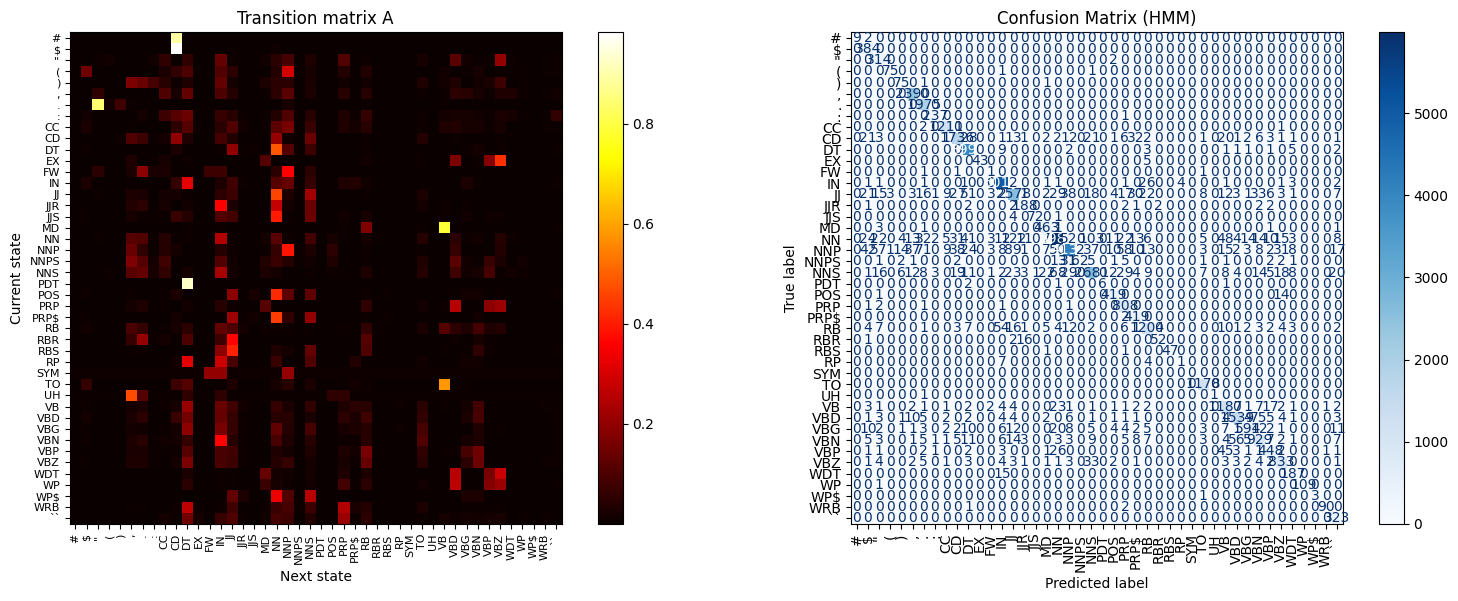


Examples where Viterbi corrects the baseline dictionary:
  Word: 'Rockwell' | True: NNP | Dico: NN | HMM: NNP
  Word: 'supply' | True: VB | Dico: NN | HMM: VB
  Word: 'bulkheads' | True: NNS | Dico: NN | HMM: NNS
  Word: 'Rockwell' | True: NNP | Dico: NN | HMM: NNP
  Word: 'concern' | True: VBP | Dico: NN | HMM: VBP
  Word: 'Carlucci' | True: NNP | Dico: NN | HMM: NNP
  Word: 'Carlucci' | True: NNP | Dico: NN | HMM: NNP
  Word: 'accepted' | True: VBD | Dico: VBN | HMM: VBD
  Word: 'Carlyle' | True: NNP | Dico: NN | HMM: NNP
  Word: 'Meador' | True: NNP | Dico: NN | HMM: NNP


In [12]:
# Qualitative Analysis

# 1) Transition matrix visualization
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Transition matrix A
im = axes[0].imshow(A, cmap='hot', interpolation='nearest')
axes[0].set_title("Transition matrix A")
axes[0].set_xlabel("Next state")
axes[0].set_ylabel("Current state")
axes[0].set_xticks(range(nCles))
axes[0].set_xticklabels(cles, rotation=90, fontsize=8)
axes[0].set_yticks(range(nCles))
axes[0].set_yticklabels(cles, fontsize=8)
plt.colorbar(im, ax=axes[0])

# Most probable transitions
print("Most probable transitions (top 10):")
flat_idx = np.argsort(A, axis=None)[::-1][:10]
for idx in flat_idx:
    i, j = divmod(idx, nCles)
    print(f"  {cles[i]} -> {cles[j]}: {A[i,j]:.4f}")

# 2) Confusion matrix
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

all_true = []
all_pred = []
for x, q in zip(allxT, allqT):
    pred, _ = viterbi(x, Pi, A, B)
    all_true.extend([int(qi) for qi in q])
    all_pred.extend([int(pi) for pi in pred])

cm = confusion_matrix(all_true, all_pred, labels=range(nCles))
disp = ConfusionMatrixDisplay(cm, display_labels=cles)
disp.plot(ax=axes[1], cmap='Blues', xticks_rotation=90, values_format='d')
axes[1].set_title("Confusion Matrix (HMM)")
plt.tight_layout()
plt.show()

# 3) Examples corrected by Viterbi
ind2mots = {v: k for k, v in mots2ind.items()}
ind2cles = {v: k for k, v in cles2ind.items()}

print("\nExamples where Viterbi corrects the baseline dictionary:")
found = 0
for doc, x, q in zip(alldocsT, allxT, allqT):
    pred_hmm, _ = viterbi(x, Pi, A, B)
    for i, (word, true_pos) in enumerate(doc):
        dico_pred = dico.get(word, default_pos)
        hmm_pred = ind2cles.get(int(pred_hmm[i]), "UNK")
        if dico_pred != true_pos and hmm_pred == true_pos:
            print(f"  Word: '{word}' | True: {true_pos} | Dico: {dico_pred} | HMM: {hmm_pred}")
            found += 1
            if found >= 10:
                break
    if found >= 10:
        break

# 2) Conditional Random Fields (CRF)

**CRF are disciminative models** representing the conditional distribution $P( \mathbf{y} | \mathbf{x} , \mathbf{w})$:

$$ P( \mathbf{y} | \mathbf{x} , \mathbf{w})  = \frac{e^{\mathbf{w}^T  \psi(\mathbf{x},\mathbf{y}) } }{\sum\limits_{y' \in \mathcal{y}}e^{\mathbf{w}^T  \psi(\mathbf{x},\mathbf{y}') } } $$ 
        
**In 'linear-chain' CRFs**, the feature functions include **unary terms $u_k$** ($\sim$ $\mathbf{B}$ matrix in HMMs) and **pairwise terms $p_k$** ($\sim$ $\mathbf{A}$ matrix in HMMs):

$$ \mathbf{w}^T \psi(\mathbf{x},\mathbf{y}) = \sum\limits_{t=1}^T \sum_{k=1}^K F_k(y_{t-1}, y_t, \mathbf{x})  =   \sum\limits_{t=1}^T \sum_{k=1}^K \left[ u_k(y_t, \mathbf{x}) + p_k(y_{t-1}, y_t, \mathbf{x}) \right]$$

[<img src="https://thome.isir.upmc.fr/classes/RITAL/crf-obs2.png" width="800" >](https://thome.isir.upmc.fr/classes/RITAL/crf-obs2.png)


We can directly use resources from nltk: 
- [CRFTagger](https://tedboy.github.io/nlps/generated/generated/nltk.CRFTagger.html)
- [PerceptronTagger](https://www.nltk.org/_modules/nltk/tag/perceptron.html)

In [13]:
#!pip install python-crfsuite
from nltk.tag.crf import CRFTagger
tagger = CRFTagger()
tagger.train(alldocs, 'out/crf.model') # training



In [16]:
# CRF evaluation
correct = 0
total = 0
for doc in alldocsT:
    words = [w for w, _ in doc]
    true_tags = [pos for _, pos in doc]
    pred_tags = tagger.tag(words)
    for (_, pred_pos), true_pos in zip(pred_tags, true_tags):
        if pred_pos == true_pos:
            correct += 1
        total += 1

print(f"{correct} good predictions in test over {total}")
print(f"Accuracy: {correct/total:.4f}")

46020 good predictions in test over 47377
Accuracy: 0.9714


### Training and evaluating the model, as before

Check: 1720 bonnes réponses

In [14]:
# perceptron
from nltk.tag.perceptron    import PerceptronTagger
tagger = PerceptronTagger(load=False)
tagger.train(alldocs)

In [17]:
# Perceptron evaluation
correct = 0
total = 0
for doc in alldocsT:
    words = [w for w, _ in doc]
    true_tags = [pos for _, pos in doc]
    pred_tags = tagger.tag(words)
    for (_, pred_pos), true_pos in zip(pred_tags, true_tags):
        if pred_pos == true_pos:
            correct += 1
        total += 1

print(f"{correct} good predictions in test over {total}")
print(f"Accuracy: {correct/total:.4f}")

46020 good predictions in test over 47377
Accuracy: 0.9714


Check: 1737 bonnes réponses

# Going further

- We test the application for PoS, we can run similar experiments for chunking (see parsing indication, very simple to load data)
- Run  experiement on the larger dataset. This dataset is still largely used in research. This work can thus be included in your resume :)
- Work will be purshed with word embeddings (next practical), and for [NER](https://www.clips.uantwerpen.be/conll2003/ner/) with RNNs (X. Tannier)
- [State-of-the-art resources](https://github.com/stanfordnlp/stanza/)